<a href="https://colab.research.google.com/github/triastrale/analisis-kausal-penyebab-pembelian-impulsif/blob/main/src/dowhy/Causal_Inference_DoWhy_SCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install dowhy
!pip install networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 59.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from dowhy import gcm

DoWhy

In [ ]:
data = pd.read_csv(
    '/content/drive/MyDrive/Histori Skripsi/DoWhy/Raw Data_Paylater and Non Paylater User_Average_Final.csv',
    sep=';',
    engine='python'
)

data.head()

,Gender,E-Paylater User Status,Educational Background,Age,Job Status,Monthly Income,Average monthly expenditure for online shopping in relation to monthly income,IBB,P,SI,H,SC,NE
0,2,1,3,27,2,3,1,2.50,3.00,1.67,3.50,3.6,3.0
1,1,2,1,22,1,2,2,1.75,3.25,2.00,4.00,3.4,4.8
2,1,1,1,22,1,2,1,3.00,3.00,3.17,4.00,4.0,3.0
3,2,2,3,22,1,1,1,4.00,4.00,4.00,4.00,3.6,1.2
4,1,2,3,22,2,6,1,1.00,2.00,1.83,3.25,3.2,2.8


In [ ]:
graph = nx.DiGraph()

graph.add_edges_from([
    ('Gender', 'H'),
    ('Gender', 'Monthly Income'),
    ('SI', 'SC'),
    ('SI', 'IBB'),
    ('Educational Background', 'Job Status'),
    ('Educational Background', 'E-Paylater User Status'),
    ('Educational Background', 'SC'),
    ('Job Status', 'Monthly Income'),
    ('Job Status', 'E-Paylater User Status'),
    ('H', 'IBB'),
    ('H', 'SC'),
    ('P', 'SI'),
    ('P', 'E-Paylater User Status'),
    ('P', 'H'),
    ('IBB', 'SC'),
    ('IBB', 'NE'),
    ('Age', 'NE'),
    ('E-Paylater User Status', 'SI')
])

In [ ]:
causal_model = gcm.StructuralCausalModel(graph)

In [ ]:
gcm.auto.assign_causal_mechanisms(
    causal_model,
    data
)

In [ ]:
gcm.fit(
    causal_model,
    data
)

Fitting causal mechanism of node Age: 100%|██████████| 12/12 [00:00<00:00, 13.64it/s]


Test permutations of given graph: 100%|██████████| 50/50 [08:42<00:00, 10.46s/it]


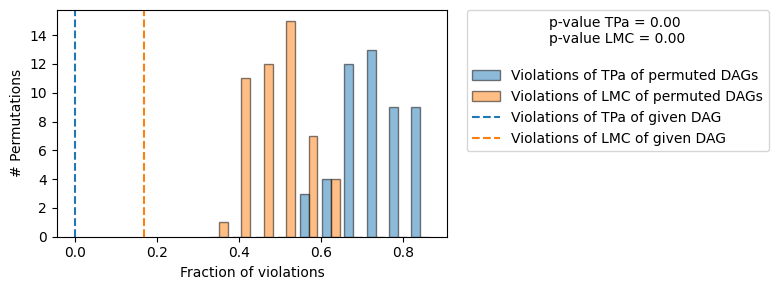

Evaluated the performance of the causal mechanisms and the invertibility assumption of the causal mechanisms and the overall average KL divergence between generated and observed distribution and the graph structure. The results are as follows:

==== Evaluation of Causal Mechanisms ====
The used evaluation metrics are:
- KL divergence (only for root-nodes): Evaluates the divergence between the generated and the observed distribution.
- Mean Squared Error (MSE): Evaluates the average squared differences between the observed values and the conditional expectation of the causal mechanisms.
- Normalized MSE (NMSE): The MSE normalized by the standard deviation for better comparison.
- R2 coefficient: Indicates how much variance is explained by the conditional expectations of the mechanisms. Note, however, that this can be misleading for nonlinear relationships.
- F1 score (only for categorical non-root nodes): The harmonic mean of the precision and recall indicating the goodness of the under

In [ ]:
validation_summary = gcm.evaluate_causal_model(
    causal_model,
    data
)

print(validation_summary)

In [ ]:
#Simulasi intervensi (Social Influence)
intervention_samples = gcm.interventional_samples(
    causal_model,
    interventions={
        "SI": lambda x: x + 1
    },
    observed_data=data
)

In [ ]:
print("Original Impulsive Buying Behavior")
print(data["IBB"].mean())

print("\nAfter intervention")
print(intervention_samples["IBB"].mean())

Original Impulsive Buying Behavior
2.756172839506173

After intervention
3.1540469257459223


In [ ]:
#Simulasi intervensi (Happiness)
intervention_samples = gcm.interventional_samples(
    causal_model,
    interventions={
        "H": lambda x: x + 1
    },
    observed_data=data
)

In [ ]:
print("Original Impulsive Buying Behavior")
print(data["IBB"].mean())

print("\nAfter intervention")
print(intervention_samples["IBB"].mean())

Original Impulsive Buying Behavior
2.756172839506173

After intervention
3.0073501666073192


In [ ]:
#Simulasi intervensi (H + SI)
intervention_samples = gcm.interventional_samples(
    causal_model,
    interventions={
        "H": lambda x: x + 1,
        'SI': lambda x: x + 1
    },
    observed_data=data
)

In [ ]:
print("Original Impulsive Buying Behavior")
print(data["IBB"].mean())

print("\nAfter intervention")
print(intervention_samples["IBB"].mean())

Original Impulsive Buying Behavior
2.756172839506173

After intervention
3.276635701362583
